# Week 14 - Bivariate Analysis 2, Statistics - Week 2

# 1. Lesson: no lesson this week.

# 2. Weekly graph question

What is your opinion of the graph below?  What are its positive or negative qualities?  How would you fix it?

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import datetime

In [2]:
size = 5
interval = 30
start = datetime.datetime(2024, 1, 1)
  
lst = [start + datetime.timedelta(days=num_days) * interval for num_days in range(size)]

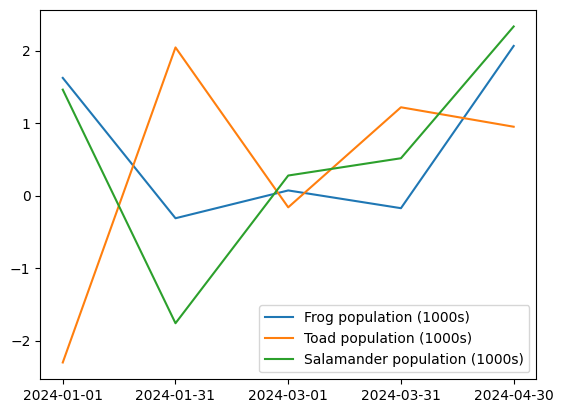

In [3]:
np.random.seed(1)
plt.plot(lst, np.random.normal(size = size) + 0.3 * np.arange(size), label = "Frog population (1000s)")
plt.plot(lst, np.random.normal(size = size) + 0.3 * np.arange(size), label = "Toad population (1000s)")
plt.plot(lst, np.random.normal(size = size) + 0.3 * np.arange(size), label = "Salamander population (1000s)")
plt.xticks(lst)
plt.legend()

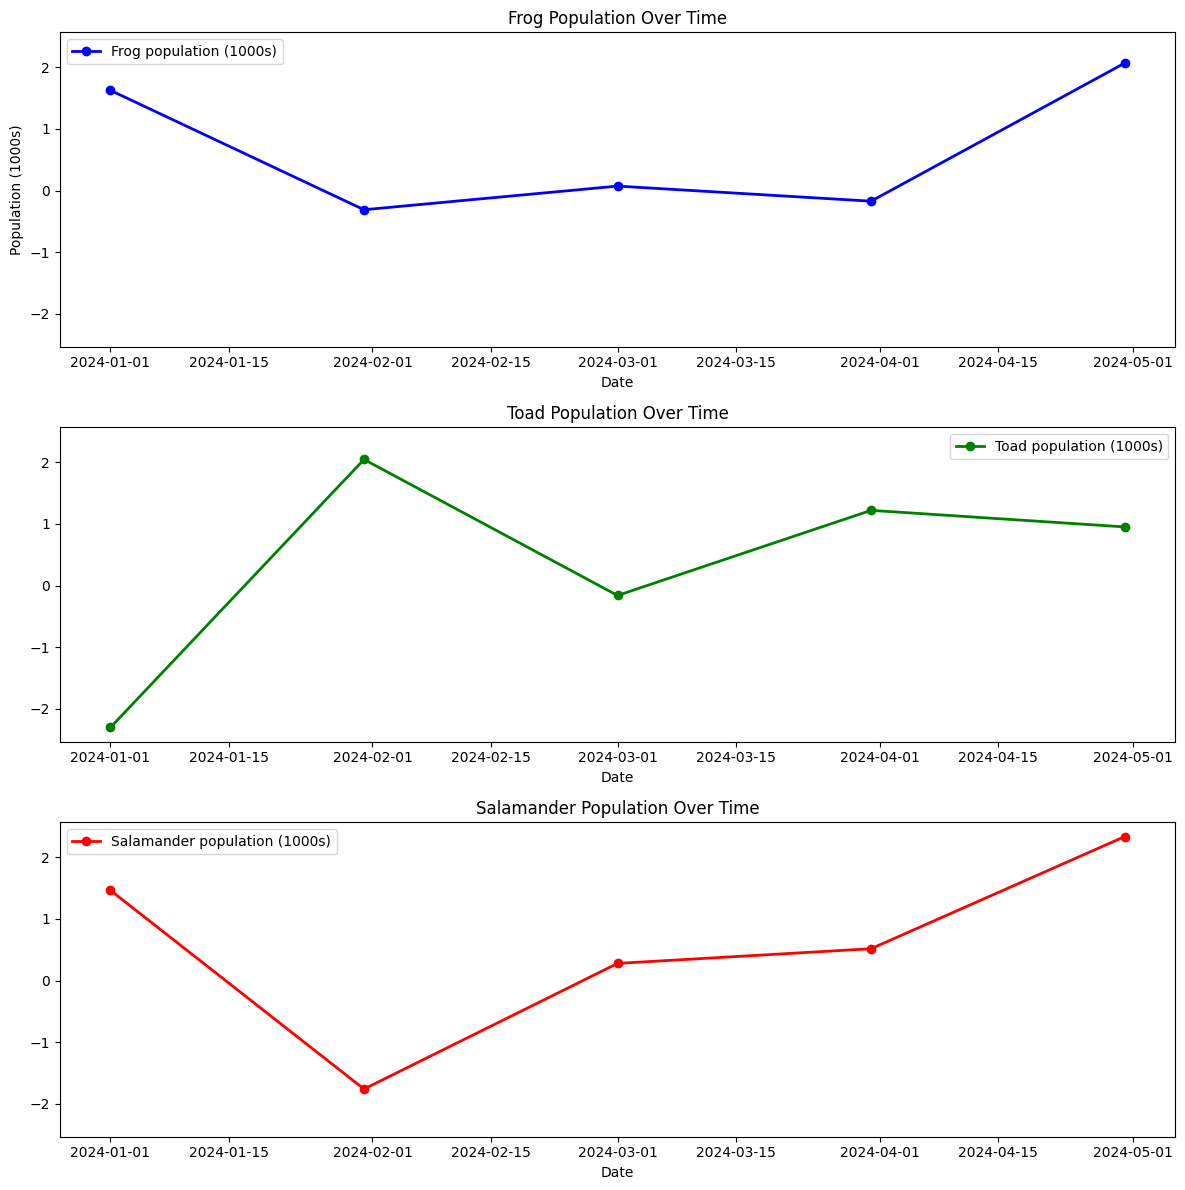

In [10]:
# Original data generation (seed fixed for reproducibility)
np.random.seed(1)
size = 5
interval = 30
start = datetime.datetime(2024, 1, 1)
lst = [start + datetime.timedelta(days=num_days) * interval for num_days in range(size)]
# Data
frog = np.random.normal(size=size) + 0.3 * np.arange(size)
toad = np.random.normal(size=size) + 0.3 * np.arange(size)
salamander = np.random.normal(size=size) + 0.3 * np.arange(size)
# Improved graph: Using small multiples (spatial separation)
fig, axs = plt.subplots(3, 1, figsize=(12, 12), sharey=True)  # Horizontal separation
# Frog
axs[0].plot(lst, frog, label="Frog population (1000s)", color='blue', linewidth=2, marker='o')
axs[0].set_title("Frog Population Over Time")
axs[0].set_xlabel("Date")
axs[0].set_ylabel("Population (1000s)")
axs[0].legend()
# Toad
axs[1].plot(lst, toad, label="Toad population (1000s)", color='green', linewidth=2, marker='o')
axs[1].set_title("Toad Population Over Time")
axs[1].set_xlabel("Date")
axs[1].legend()
# Salamander
axs[2].plot(lst, salamander, label="Salamander population (1000s)", color='red', linewidth=2, marker='o')
axs[2].set_title("Salamander Population Over Time")
axs[2].set_xlabel("Date")
axs[2].legend()
plt.tight_layout()
plt.show()

### My Opinion on the Graph

The graph shows changes in "Frog population (1000s)", "Toad population (1000s)", and "Salamander population (1000s)" over time (from 2024 to 2025). The data appears to be randomly generated, with overlapping lines.

#### Positive Qualities
- It uses a simple line graph, which is suitable for time-series data to show trends over time.
- Includes a legend, making it clear what each line represents.
- X-axis labels with dates help understand the timeline.
- The data shows similar patterns, which fits a comparison purpose.

#### Negative Qualities
- **Spaghetti Graph Issue**: The lines overlap heavily, making it hard to distinguish individual trends. As discussed in *Storytelling with Data* Chapter 9 Case Study 4, this scatters attention and prevents focus on specific lines.
- Colors are similar or lack contrast (default matplotlib colors), with insufficient preattentive attributes.
- Y-axis scale is unclear (population in 1000s, but narrow range may exaggerate changes).
- Data is randomly generated, lacking real meaning (appears noisy in practice).
- Missing title or detailed axis labels: "Population" unit isn't explicit, and no overall graph title.

#### How to Fix It
- **Emphasize One Line at a Time**: Use color, thickness, and markers to highlight key lines; gray out others for background.
- **Spatial Separation**: Apply small multiples (separate graphs side-by-side).
- **Simplify Data**: Remove unnecessary lines or add averages/trend lines.
- **Improved Design**: Add a title, clarify labels, increase color contrast. Avoid spaghetti as per Chapter 9.
- **Example Code for Improvement**: Use the provided code to create small multiples, enhancing readability with titles and labels.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Run t-tests and Mann Whitney U tests to compare different sets of numbers.
  * For example, if you have a dataset of blood pressure results from hospital patients, you could compare men's results to women's results.
* Run ANOVA tests to compare more than two sets of numbers.
  * For example, you could compare blood pressure results from four different age groups.
* Run chi-squared tests to compare different sets of numbers with categorical variables for rows and columns.
  * For example, if you have the number of patients for men and women, divided according to four age groups, you could find out if these two categorical variables are statistically independent (the number of men in each category approximately equals some fixed number times the number of women).

In [4]:
import os
import kagglehub
from kagglehub import KaggleDatasetAdapter
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import GridSearchCV, cross_val_score

print(os.listdir())
print(os.getcwd()) 

path = kagglehub.dataset_download("abcbbong/bu-699-o2")

print("Path to dataset files:", path)



df_fraud_train = pd.read_csv(os.path.join(path, 'fraud_train_processed.csv'))
df_fraud_test = pd.read_csv(os.path.join(path, 'fraud_test_processed.csv'))          
df_credit_approval = pd.read_csv(os.path.join(path, 'credit_approval_processed.csv'))
df_loan_default = pd.read_csv(os.path.join(path, 'loan_default_processed.csv'))

C:\Users\abcbb\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


['.git', '.gitignore', '.venv', 'answer.png', 'final_image.png', 'final_image_english.png', 'histogram.png', 'image_modified.png', 'OMDS-MODB2-Week1-Lee-JaeHoon.ipynb', 'OMDS-MODB2-Week10-Lee-JaeHoon.ipynb', 'OMDS-MODB2-Week11-Lee-JaeHoon.ipynb', 'OMDS-MODB2-Week12-Lee-JaeHoon.ipynb', 'OMDS-MODB2-Week13-Lee-JaeHoon.ipynb', 'OMDS-MODB2-Week14-Lee-JaeHoon.ipynb', 'OMDS-MODB2-Week2-Lee-JaeHoon.ipynb', 'OMDS-MODB2-Week3-Lee-JaeHoon.ipynb', 'OMDS-MODB2-Week4-Lee-JaeHoon.ipynb', 'OMDS-MODB2-Week5-Lee-JaeHoon.ipynb', 'OMDS-MODB2-Week6-Lee-JaeHoon.ipynb', 'OMDS-MODB2-Week7-Lee-JaeHoon.ipynb', 'OMDS-MODB2-Week8-Lee-JaeHoon.ipynb', 'OMDS-MODB2-Week9-Lee-JaeHoon.ipynb', 'README.md', 'threeclouds.png', 'twoclouds.png']
e:\BU\CDSDX 699 O2\Homework
Path to dataset files: C:\Users\abcbb\.cache\kagglehub\datasets\abcbbong\bu-699-o2\versions\3


In [15]:
from scipy import stats

In [16]:
fraud_amt = df_fraud_train[df_fraud_train['is_fraud'] == 1]['amt']
non_fraud_amt = df_fraud_train[df_fraud_train['is_fraud'] == 0]['amt']
t_stat, p_val = stats.ttest_ind(fraud_amt, non_fraud_amt)
print(f"t-test (Fraud vs Non-Fraud Amount): t-stat={t_stat:.2f}, p-value={p_val:.4f}")

t-test (Fraud vs Non-Fraud Amount): t-stat=256.08, p-value=0.0000


In [26]:
male_income = df_credit_approval[df_credit_approval['Applicant_Gender_M      '] == 1 ]['Total_Income']
female_income = df_credit_approval[df_credit_approval['Applicant_Gender_F      '] == 1 ]['Total_Income']
u_stat, p_val_u = stats.mannwhitneyu(male_income, female_income)
print(f"Mann-Whitney U (Male vs Female Income): U-stat={u_stat:.2f}, p-value={p_val_u:.4f}")

Mann-Whitney U (Male vs Female Income): U-stat=94866327.50, p-value=0.0000


In [30]:
groups = [df_loan_default[df_loan_default['GGGrade'] == group]['Lend_Amount'] for group in df_loan_default['GGGrade'].unique() if group is not np.nan]
f_stat, p_val_anova = stats.f_oneway(*groups)
print(f"ANOVA (Loan Amount by GGGrade): F-stat={f_stat:.2f}, p-value={p_val_anova:.4f}")

ANOVA (Loan Amount by GGGrade): F-stat=321.71, p-value=0.0000


In [32]:
contingency_table = pd.crosstab(df_loan_default['GGGrade'], df_loan_default['Default'])
chi2, p_val_chi, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Chi-squared (GGGrade vs Default): Chi2={chi2:.2f}, p-value={p_val_chi:.4f}")
print("Contingency Table:\n", contingency_table)

Chi-squared (GGGrade vs Default): Chi2=83.35, p-value=0.0000
Contingency Table:
 Default      0     1
GGGrade             
I         9028  2082
II       15473  4059
III      15839  3484
IV        8803  2028
V         4674   902
VI        1430   311
VII        320    72


### Statistical Tests Summary

#### 1. t-test: Fraud vs Non-Fraud Transaction Amount (Fraud Dataset)
- **Result**: t-stat = 256.08, p-value = 0.0000
- **Interpretation**: Significant difference in mean amounts between fraud and non-fraud transactions (p < 0.05). Fraud transactions have much higher average amounts (positive t-stat indicates fraud mean > non-fraud mean).

#### 2. Mann-Whitney U Test: Male vs Female Income (Credit Approval Dataset)
- **Result**: U-stat = 94,866,327.50, p-value = 0.0000
- **Interpretation**: Significant difference in income distributions between males and females (p < 0.05). Likely males have higher incomes (check medians for direction).

#### 3. ANOVA: Loan Amount by GGGrade (Loan Default Dataset)
- **Result**: F-stat = 321.71, p-value = 0.0000
- **Interpretation**: Significant differences in mean loan amounts across GGGrade levels (p < 0.05). Loan amounts vary by credit grade.

#### 4. Chi-squared Test: GGGrade vs Default (Loan Default Dataset)
- **Result**: Chi2 = 83.35, p-value = 0.0000
- **Interpretation**: Significant association between GGGrade and default status (p < 0.05). Default rates differ by grade (e.g., higher in II, lower in V).

**Overall Insight**: Strong patterns in fraud amounts, gender income gaps, and credit grade impacts on loans/defaults. Suggests these variables are key for predictive modeling. Further post-hoc tests recommended.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 228-255 (chapter nine, Case Study 4 through the end of chapter 10) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

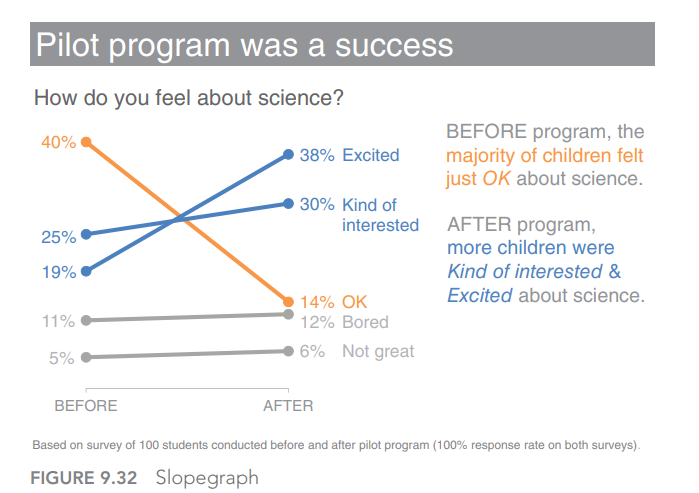

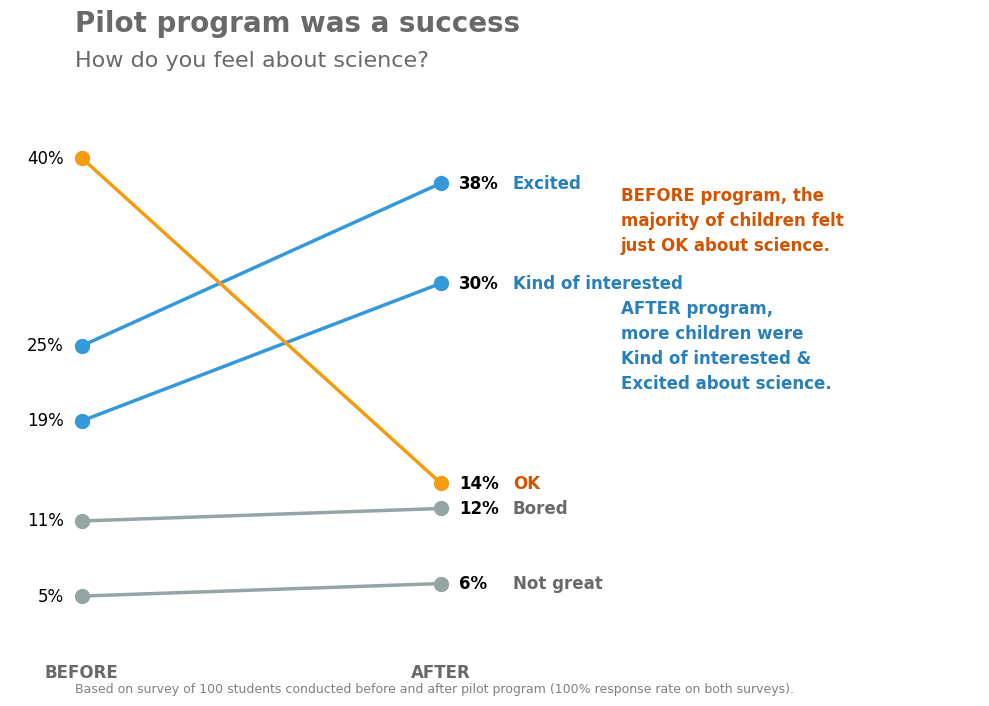

In [41]:
# 1. Data and Style Setup
# ------------------------------------
# Data to be displayed on the chart
categories = ['Excited', 'Kind of interested', 'OK', 'Bored', 'Not great']
before_values = [25, 19, 40, 11, 5]
after_values = [38, 30, 14, 12, 6]

# Assign colors for each category (similar to the image)
colors = {
    'Excited': '#3498db',           # Blue
    'Kind of interested': '#3498db', # Blue
    'OK': '#f39c12',                # Orange
    'Bored': '#95a5a6',             # Gray
    'Not great': '#95a5a6'          # Gray
}

# Colors to use for the text labels
text_colors = {
    'Excited': '#2980b9',
    'Kind of interested': '#2980b9',
    'OK': '#d35400',
    'Bored': 'dimgray',
    'Not great': 'dimgray'
}

# 2. Create the Chart
# ------------------------------------
fig, ax = plt.subplots(figsize=(10, 7))

# For each category, add lines, points, and text labels
for i, category in enumerate(categories):
    # Line connecting 'BEFORE' and 'AFTER'
    ax.plot([0, 1], [before_values[i], after_values[i]],
            color=colors[category],
            linewidth=2.5,
            solid_capstyle='round') # Make the line ends round

    # Add circular markers at both ends
    ax.scatter([0, 1], [before_values[i], after_values[i]],
               color=colors[category],
               s=100,      # Marker size
               zorder=3)   # Set z-order to appear above other elements

    # 'BEFORE' value label (left side)
    ax.text(-0.05, before_values[i], f'{before_values[i]}%', ha='right', va='center', fontsize=12)

    # 'AFTER' value label (right side)
    ax.text(1.05, after_values[i], f'{after_values[i]}%', ha='left', va='center', fontsize=12, fontweight='bold')

    # 'AFTER' category name label
    ax.text(1.2, after_values[i], category, ha='left', va='center', fontsize=12, color=text_colors[category], fontweight='bold')


# 3. Chart Styling and Annotations
# ------------------------------------
# X-axis setup
ax.set_xticks([0, 1])
ax.set_xticklabels(['BEFORE', 'AFTER'], fontsize=12, fontweight='bold', color='dimgray')
ax.tick_params(axis='x', length=0) # Remove x-axis tick marks

# Remove Y-axis
ax.get_yaxis().set_visible(False)

# Remove chart borders (spines)
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)

# Title and Subtitle
fig.text(0.08, 0.95, 'Pilot program was a success', fontsize=20, fontweight='bold', color='dimgray', ha='left')
fig.text(0.08, 0.90, 'How do you feel about science?', fontsize=16, color='dimgray', ha='left')

# Add main annotations
ax.text(1.5, 35, 'BEFORE program, the\nmajority of children felt\njust OK about science.',
        ha='left', va='center', fontsize=12, color=text_colors['OK'], fontweight='bold', linespacing=1.5)
ax.text(1.5, 25, 'AFTER program,\nmore children were\nKind of interested &\nExcited about science.',
        ha='left', va='center', fontsize=12, color=text_colors['Excited'], fontweight='bold', linespacing=1.5)

# Bottom caption
fig.text(0.08, 0.005, 'Based on survey of 100 students conducted before and after pilot program (100% response rate on both surveys).',
         fontsize=9, color='gray', ha='left')

# Adjust layout and display the chart
ax.set_xlim(-0.2, 2.5) # Expand x-axis range to make room for text
ax.set_ylim(0, 45)     # Set y-axis range
plt.tight_layout(rect=[0, 0, 1, 0.88]) # Make room for the title and caption
plt.show()